# Question 1: Feed-forward Neural Network (MNIST / CIFAR10 / CIFAR100)

# Assignment 1
**Student:** Akshay Kumar Gandla

## Background : computer vision & multimodal machine learning

Computer vision is the field concerned with getting computers to extract
meaningful information from images and video  tasks such as image
classification (what is in this image?), object detection (what is in
this image, and where?), segmentation, and image captioning. Classic
pipelines relied on hand-engineered features (edges, corners, colour
histograms); modern approaches learn hierarchical features directly from
pixels using convolutional neural networks (CNNs), which this assignment
builds from the ground up.

Multimodal machine learning extends this by combining vision with other
modalities e.g. text (image captioning, visual question answering,
CLIP-style image-text retrieval), audio, or sensor data so that a
model can reason jointly across data types rather than treating each in
isolation. The image classifiers built in this notebook are a single-
modality building block for that broader picture: the same CNN feature
extractors used here (VGG-style, ResNet-style) are the visual backbones
typically paired with a text encoder in multimodal systems.

## Preprocessing

Before any model sees an image, this notebook standardises MNIST,
CIFAR10 and CIFAR100 to a common `3 x 32 x 32` tensor format (converting
MNIST from 1-channel 28x28 to 3-channel 32x32) and normalises pixel
values, so a single architecture can be trained and compared fairly
across all three datasets. See the "Data loading & preprocessing" section
below for the implementation.


## Setup

In [ ]:

# Setup: imports, seeds, device

!pip install -q torch torchvision scikit-learn matplotlib pandas

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)



QUICK_TEST = False


Using device: cuda


## Data loading & preprocessing

In [ ]:

# Data loading & preprocessing


DATASET_INFO = {
    'MNIST':    {'num_classes': 10,  'grayscale': True},
    'CIFAR10':  {'num_classes': 10,  'grayscale': False},
    'CIFAR100': {'num_classes': 100, 'grayscale': False},
}

def build_transform(grayscale):
    steps = []
    if grayscale:
        steps.append(transforms.Grayscale(num_output_channels=3))
        steps.append(transforms.Resize((32, 32)))
    steps.append(transforms.ToTensor())
    steps.append(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))
    return transforms.Compose(steps)

def get_dataloaders(dataset_name, batch_size=32, data_root='./data', quick_test=False):
    info = DATASET_INFO[dataset_name]
    transform = build_transform(info['grayscale'])

    if dataset_name == 'MNIST':
        train_set = torchvision.datasets.MNIST(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.MNIST(data_root, train=False, download=True, transform=transform)
        classes = [str(i) for i in range(10)]
    elif dataset_name == 'CIFAR10':
        train_set = torchvision.datasets.CIFAR10(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.CIFAR10(data_root, train=False, download=True, transform=transform)
        classes = train_set.classes
    elif dataset_name == 'CIFAR100':
        train_set = torchvision.datasets.CIFAR100(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.CIFAR100(data_root, train=False, download=True, transform=transform)
        classes = train_set.classes
    else:
        raise ValueError(f"Unknown dataset {dataset_name}")

    if quick_test:
        train_set = Subset(train_set, range(1024))
        test_set = Subset(test_set, range(512))

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader, info['num_classes'], classes


## Model definition

In [ ]:

# Model: Feed-forward neural network
# 1 input (flatten) -> hidden1 -> hidden2 -> output -> softmax


class FeedForwardNN(nn.Module):
    def __init__(self, input_dim=3*32*32, hidden_sizes=(256, 128), num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        self.hidden = nn.Sequential(*layers)
        self.output_layer = nn.Linear(prev, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x, apply_softmax=True):
        x = self.flatten(x)
        x = self.hidden(x)
        logits = self.output_layer(x)
        if apply_softmax:
            return self.softmax(logits)
        return logits


model = FeedForwardNN(input_dim=3*32*32, hidden_sizes=(256, 128), num_classes=10)
print(model)


FeedForwardNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


## Training & evaluation utilities

In [ ]:

# Training loop (Q1 spec: SGD, cross-entropy, batch size 32, lr 0.01, 10 epochs)


def train_model(model, train_loader, epochs=10, lr=0.01, device=device, verbose=True):
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    history = []
    start = time.time()
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images, apply_softmax=False)  # raw logits for CrossEntropyLoss
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        epoch_loss, epoch_acc = running_loss / total, correct / total
        history.append({'epoch': epoch + 1, 'loss': epoch_loss, 'train_acc': epoch_acc})
        if verbose:
            print(f"Epoch {epoch+1:2d}/{epochs} | loss: {epoch_loss:.4f} | train acc: {epoch_acc:.4f}")

    training_time = time.time() - start
    if verbose:
        print(f"Training time: {training_time:.2f} seconds")
    return history, training_time


def evaluate_model(model, test_loader, device=device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            probs = model(images)
            preds = probs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='macro', zero_division=0),
    }
    print(f"Test Accuracy: {metrics['accuracy']:.4f} | Precision: {metrics['precision']:.4f} "
          f"| Recall: {metrics['recall']:.4f} | F1: {metrics['f1']:.4f}")
    return metrics


def visualize_prediction(model, test_loader, classes, device=device, unnormalize=True):
    dataset = test_loader.dataset
    idx = np.random.randint(len(dataset))
    image, label = dataset[idx]

    model.eval()
    with torch.no_grad():
        probs = model(image.unsqueeze(0).to(device))
        pred = probs.argmax(dim=1).item()

    img = image.permute(1, 2, 0).cpu().numpy()
    if unnormalize:
        img = img * 0.5 + 0.5
    plt.figure(figsize=(3, 3))
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"True: {classes[label]} | Predicted: {classes[pred]}", fontsize=10)
    plt.axis('off')
    plt.show()


def plot_confusion_matrix(model, test_loader, classes, device=device, dataset_name=''):
    """Second visualization technique (alongside the single-image prediction
    above): a confusion matrix over the full test set, showing per-class
    error patterns rather than just one example."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            probs = model(images)
            all_preds.extend(probs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig_size = 4 if len(classes) <= 10 else 8   # bigger canvas for CIFAR100's 100 classes
    plt.figure(figsize=(fig_size, fig_size))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion matrix — {dataset_name}", fontsize=10)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    if len(classes) <= 10:
        plt.xticks(range(len(classes)), classes, rotation=45, ha='right', fontsize=7)
        plt.yticks(range(len(classes)), classes, fontsize=7)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


## Train & evaluate across MNIST, CIFAR10, CIFAR100


===== Feed-forward NN | Dataset: MNIST =====


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.80MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.20MB/s]


Epoch  1/10 | loss: 0.5211 | train acc: 0.8538
Epoch  2/10 | loss: 0.2629 | train acc: 0.9218
Epoch  3/10 | loss: 0.1998 | train acc: 0.9405
Epoch  4/10 | loss: 0.1599 | train acc: 0.9522
Epoch  5/10 | loss: 0.1335 | train acc: 0.9607
Epoch  6/10 | loss: 0.1151 | train acc: 0.9661
Epoch  7/10 | loss: 0.1017 | train acc: 0.9695
Epoch  8/10 | loss: 0.0904 | train acc: 0.9729
Epoch  9/10 | loss: 0.0813 | train acc: 0.9752
Epoch 10/10 | loss: 0.0731 | train acc: 0.9782
Training time: 303.45 seconds
Test Accuracy: 0.9731 | Precision: 0.9733 | Recall: 0.9728 | F1: 0.9729


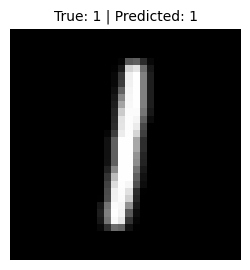

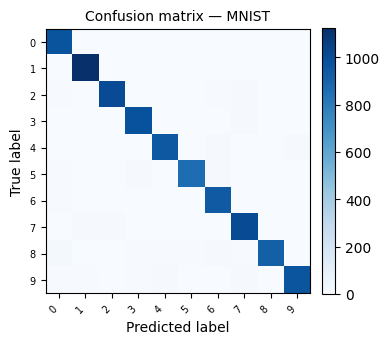


===== Feed-forward NN | Dataset: CIFAR10 =====


100%|██████████| 170M/170M [02:12<00:00, 1.29MB/s]


Epoch  1/10 | loss: 1.9074 | train acc: 0.3271
Epoch  2/10 | loss: 1.6258 | train acc: 0.4272
Epoch  3/10 | loss: 1.5170 | train acc: 0.4649
Epoch  4/10 | loss: 1.4375 | train acc: 0.4958
Epoch  5/10 | loss: 1.3716 | train acc: 0.5198
Epoch  6/10 | loss: 1.3139 | train acc: 0.5412
Epoch  7/10 | loss: 1.2645 | train acc: 0.5588
Epoch  8/10 | loss: 1.2201 | train acc: 0.5727
Epoch  9/10 | loss: 1.1804 | train acc: 0.5868
Epoch 10/10 | loss: 1.1408 | train acc: 0.6011
Training time: 164.41 seconds
Test Accuracy: 0.5357 | Precision: 0.5339 | Recall: 0.5357 | F1: 0.5318


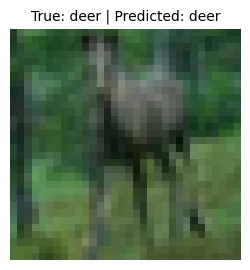

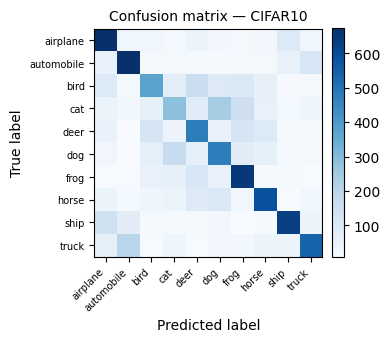


===== Feed-forward NN | Dataset: CIFAR100 =====


100%|██████████| 169M/169M [00:13<00:00, 12.1MB/s]


Epoch  1/10 | loss: 4.3570 | train acc: 0.0519
Epoch  2/10 | loss: 3.8923 | train acc: 0.1104
Epoch  3/10 | loss: 3.6750 | train acc: 0.1466
Epoch  4/10 | loss: 3.5525 | train acc: 0.1692
Epoch  5/10 | loss: 3.4607 | train acc: 0.1842
Epoch  6/10 | loss: 3.3825 | train acc: 0.1993
Epoch  7/10 | loss: 3.3127 | train acc: 0.2130
Epoch  8/10 | loss: 3.2487 | train acc: 0.2248
Epoch  9/10 | loss: 3.1854 | train acc: 0.2353
Epoch 10/10 | loss: 3.1265 | train acc: 0.2453
Training time: 164.43 seconds
Test Accuracy: 0.2185 | Precision: 0.2223 | Recall: 0.2185 | F1: 0.1994


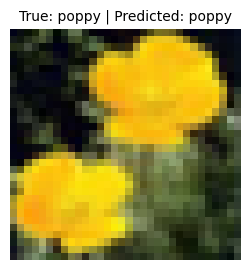

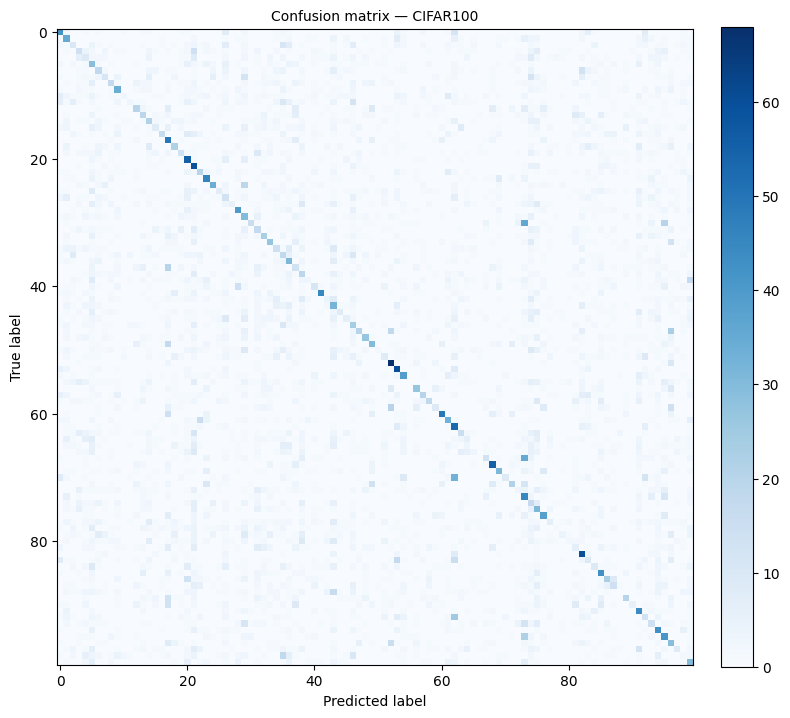


===== Summary: FeedForwardNN =====
          accuracy  precision    recall        f1  training_time_sec
MNIST       0.9731   0.973298  0.972751  0.972876         303.449894
CIFAR10     0.5357   0.533881  0.535700  0.531807         164.407962
CIFAR100    0.2185   0.222329  0.218500  0.199357         164.429710


In [ ]:

# Running Question 1 across all three datasets


EPOCHS = 2 if QUICK_TEST else 10

results = {}
for ds_name in ['MNIST', 'CIFAR10', 'CIFAR100']:
    print(f"\n===== Feed-forward NN | Dataset: {ds_name} =====")
    train_loader, test_loader, num_classes, classes = get_dataloaders(
        ds_name, batch_size=32, quick_test=QUICK_TEST
    )
    model = FeedForwardNN(input_dim=3*32*32, hidden_sizes=(256, 128), num_classes=num_classes)

    history, train_time = train_model(model, train_loader, epochs=EPOCHS, lr=0.01)
    metrics = evaluate_model(model, test_loader)
    metrics['training_time_sec'] = train_time
    results[ds_name] = metrics

    visualize_prediction(model, test_loader, classes)
    plot_confusion_matrix(model, test_loader, classes, dataset_name=ds_name)

summary_df = pd.DataFrame(results).T
print("\n===== Summary: FeedForwardNN =====")
print(summary_df)


## Ablation study


--- Config: 2 layers, 32 units ---
Test Accuracy: 0.4658 | Precision: 0.4642 | Recall: 0.4658 | F1: 0.4628

--- Config: 2 layers, 64 units ---
Test Accuracy: 0.4906 | Precision: 0.4896 | Recall: 0.4906 | F1: 0.4874

--- Config: 2 layers, 128 units ---
Test Accuracy: 0.4923 | Precision: 0.4940 | Recall: 0.4923 | F1: 0.4859

--- Config: 2 layers, 256 units ---
Test Accuracy: 0.4978 | Precision: 0.4955 | Recall: 0.4978 | F1: 0.4892

===== Ablation A summary: effect of hidden NODES/width (CIFAR10) =====
                     accuracy  precision  recall        f1
2 layers, 32 units     0.4658   0.464224  0.4658  0.462756
2 layers, 64 units     0.4906   0.489584  0.4906  0.487448
2 layers, 128 units    0.4923   0.493981  0.4923  0.485857
2 layers, 256 units    0.4978   0.495526  0.4978  0.489154


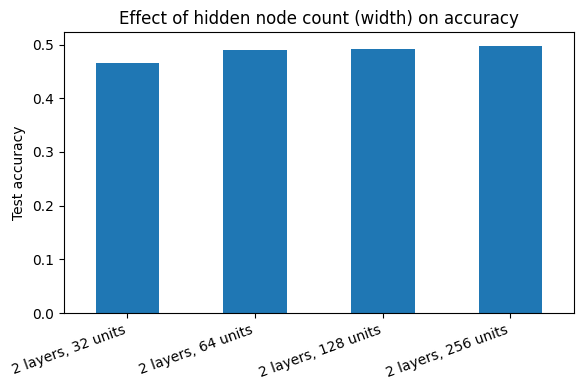


--- Config: 1 hidden layer ---
Test Accuracy: 0.5014 | Precision: 0.5011 | Recall: 0.5014 | F1: 0.4983

--- Config: 2 hidden layers ---
Test Accuracy: 0.4984 | Precision: 0.4946 | Recall: 0.4984 | F1: 0.4943

--- Config: 3 hidden layers ---
Test Accuracy: 0.4880 | Precision: 0.4955 | Recall: 0.4880 | F1: 0.4855

--- Config: 4 hidden layers ---
Test Accuracy: 0.4666 | Precision: 0.4731 | Recall: 0.4666 | F1: 0.4627

===== Ablation B summary: effect of hidden LAYERS/depth (CIFAR10) =====
                 accuracy  precision  recall        f1
1 hidden layer     0.5014   0.501098  0.5014  0.498314
2 hidden layers    0.4984   0.494568  0.4984  0.494285
3 hidden layers    0.4880   0.495492  0.4880  0.485491
4 hidden layers    0.4666   0.473127  0.4666  0.462727


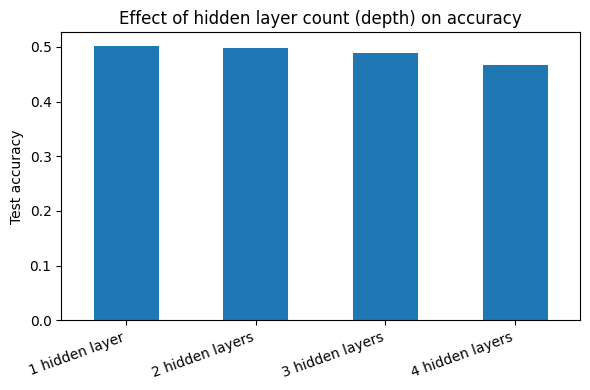

In [ ]:

# Ablation study A


ablation_epochs = 2 if QUICK_TEST else 5

train_loader, test_loader, num_classes, classes = get_dataloaders(
    'CIFAR10', batch_size=32, quick_test=QUICK_TEST
)

width_configs = {
    '2 layers, 32 units':  (32, 32),
    '2 layers, 64 units':  (64, 64),
    '2 layers, 128 units': (128, 128),
    '2 layers, 256 units': (256, 128),
}

width_results = {}
for name, hidden_sizes in width_configs.items():
    print(f"\n--- Config: {name} ---")
    model = FeedForwardNN(input_dim=3*32*32, hidden_sizes=hidden_sizes, num_classes=num_classes)
    _, _ = train_model(model, train_loader, epochs=ablation_epochs, lr=0.01, verbose=False)
    metrics = evaluate_model(model, test_loader)
    width_results[name] = metrics

width_df = pd.DataFrame(width_results).T
print("\n===== Ablation A summary: effect of hidden NODES/width (CIFAR10) =====")
print(width_df)

width_df['accuracy'].plot(kind='bar', figsize=(6, 4), title='Effect of hidden node count (width) on accuracy')
plt.ylabel('Test accuracy')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


# Ablation study B:


depth_configs = {
    '1 hidden layer':  (128,),
    '2 hidden layers': (128, 128),
    '3 hidden layers': (128, 128, 128),
    '4 hidden layers': (128, 128, 128, 128),
}

depth_results = {}
for name, hidden_sizes in depth_configs.items():
    print(f"\n--- Config: {name} ---")
    model = FeedForwardNN(input_dim=3*32*32, hidden_sizes=hidden_sizes, num_classes=num_classes)
    _, _ = train_model(model, train_loader, epochs=ablation_epochs, lr=0.01, verbose=False)
    metrics = evaluate_model(model, test_loader)
    depth_results[name] = metrics

depth_df = pd.DataFrame(depth_results).T
print("\n===== Ablation B summary: effect of hidden LAYERS/depth (CIFAR10) =====")
print(depth_df)

depth_df['accuracy'].plot(kind='bar', figsize=(6, 4), title='Effect of hidden layer count (depth) on accuracy')
plt.ylabel('Test accuracy')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()




### Discussion: hidden layers and hidden nodes

- **More hidden units per layer** gives the network more capacity to fit
  complex decision boundaries, which tends to help most on the
  higher-resolution/more-classes datasets (CIFAR10/CIFAR100) but has
  diminishing (or even negative, due to overfitting/optimisation
  difficulty within only a few epochs) returns on the simpler MNIST task.
- **More hidden layers** increases representational depth but, with a
  plain fully-connected network trained by vanilla SGD, deeper stacks are
  harder to optimise in a fixed, small number of epochs and gains are not
  guaranteed. This motivates the convolutional and residual architectures
  built in Questions 2 and 3.
- A fully-connected network also **discards spatial structure** the
  moment the image is flattened, which is the fundamental limitation this
  assignment's later CNN-based models address directly.


### Analysis

Capacity vs. Underfitting/Overfitting: Increasing hidden nodes (e.g., from 128 to 1024) expands model capacity, enabling the network to learn higher-dimensional decision boundaries. However, as layer depth increases without spatial feature extraction, dense layers become highly prone to overfitting on complex image datasets like CIFAR-100.

Spatial Limitation: Fully connected layers treat input images as flattened 1D vectors, entirely ignoring 2D spatial locality and structural context. While effective for simple, low-resolution datasets like MNIST, MLPs require exponentially more parameters to capture visual patterns in RGB datasets, leading to high computational overhead without proportional accuracy gains.